In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [435]:
df = pd.read_excel(r"C:\Users\wwwab\Downloads\Coffe_sales.xlsx")
df.head() 

,hour_of_day,cash_type,money,coffee_name,Time_of_Day,Weekday,Month_name,Weekdaysort,Monthsort,Date,Time
0,10,card,38.7,Latte,Morning,Fri,Mar,5,3,2024-03-01,15:50.5
1,12,card,38.7,Hot Chocolate,Afternoon,Fri,Mar,5,3,2024-03-01,19:22.5
2,12,card,38.7,Hot Chocolate,Afternoon,Fri,Mar,5,3,2024-03-01,20:18.1
3,13,card,28.9,Americano,Afternoon,Fri,Mar,5,3,2024-03-01,46:33.0
4,13,card,38.7,Latte,Afternoon,Fri,Mar,5,3,2024-03-01,48:14.6


In [6]:
df.isna().sum()

hour_of_day    0
cash_type      0
money          0
coffee_name    0
Time_of_Day    0
Weekday        0
Month_name     0
Weekdaysort    0
Monthsort      0
Date           0
Time           0
dtype: int64

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3547 entries, 0 to 3546
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   hour_of_day  3547 non-null   int64         
 1   cash_type    3547 non-null   object        
 2   money        3547 non-null   float64       
 3   coffee_name  3547 non-null   object        
 4   Time_of_Day  3547 non-null   object        
 5   Weekday      3547 non-null   object        
 6   Month_name   3547 non-null   object        
 7   Weekdaysort  3547 non-null   int64         
 8   Monthsort    3547 non-null   int64         
 9   Date         3547 non-null   datetime64[ns]
 10  Time         3547 non-null   object        
dtypes: datetime64[ns](1), float64(1), int64(3), object(6)
memory usage: 304.9+ KB


In [17]:
df.duplicated().sum()

np.int64(0)

In [ ]:
# أكثر ثلاث مشروبات مبيعا

In [18]:
x = df['coffee_name'].value_counts().head(3)
x

coffee_name
Americano with Milk    809
Latte                  757
Americano              564
Name: count, dtype: int64

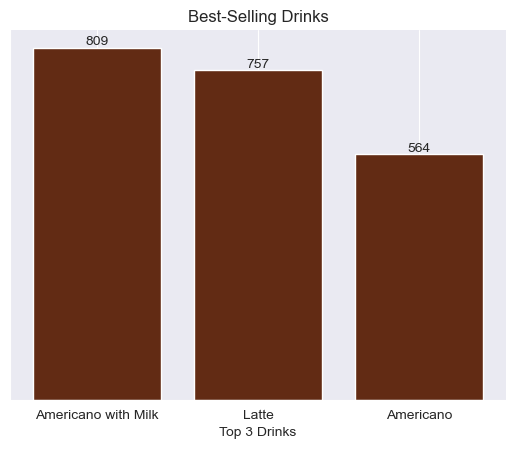

In [367]:
sns.set_style('darkgrid')
plt.bar(x.index, x.values, color = '#622B14')
plt.title('Best-Selling Drinks')
a = plt.gca()
a.spines[['top','right']].set_visible(False)
plt.yticks([])
plt.xlabel('Top 3 Drinks')
a.bar_label(a.containers[0])
plt.show()

In [ ]:
# أقل ثلاث مشروبات مبيعا

In [397]:
y = df['coffee_name'].value_counts().sort_values().head(3)
y

coffee_name
Espresso         129
Cocoa            239
Hot Chocolate    276
Name: count, dtype: int64

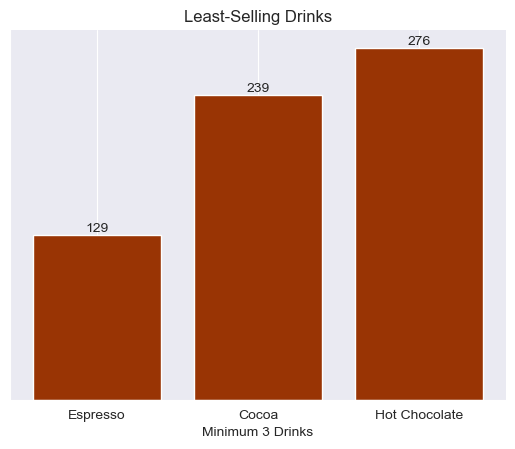

In [398]:
sns.set_style('darkgrid')
plt.bar(y.index, y.values, color = '#993404')
plt.title('Least-Selling Drinks')
a = plt.gca()
a.spines[['top','right']].set_visible(False)
plt.yticks([])
plt.xlabel('Minimum 3 Drinks')
a.bar_label(a.containers[0])
plt.show()

In [ ]:
# إيه أكتر مشروب بيجيب إيراد إجمالي

In [436]:
f = df.groupby('coffee_name')['money'].sum().sort_values(ascending=False)
f

coffee_name
Latte                  26875.30
Americano with Milk    24751.12
Cappuccino             17439.14
Americano              14650.26
Hot Chocolate           9933.46
Cocoa                   8521.16
Cortado                 7384.86
Espresso                2690.28
Name: money, dtype: float64

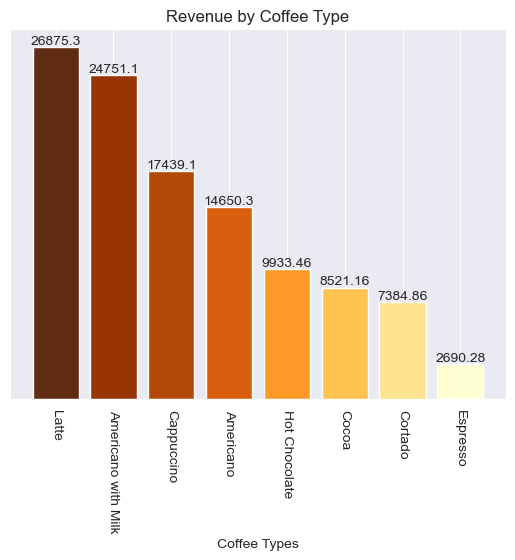

In [409]:
sns.set_style('darkgrid')
plt.bar(f.index, f.values, color =  ['#622B14','#993404','#B24909','#d95f0e','#fe9929','#fec44f','#fee391','#ffffd4'])
a = plt.gca()
a.spines[['top','right']].set_visible(False)
plt.xticks(rotation=-90)
plt.title('Revenue by Coffee Type')
plt.yticks([])
plt.xlabel('Coffee Types')
a.bar_label(a.containers[0])
plt.show()

In [150]:
print('Best-Selling Drinks')
x = df['coffee_name'].value_counts().head(3)
print(x)
print('_____________________')
print('Top 3 highest-revenue beverage')
y = df.groupby('coffee_name')['money'].sum().sort_values(ascending=False).head(3)
print(y)

Best-Selling Drinks
coffee_name
Americano with Milk    809
Latte                  757
Americano              564
Name: count, dtype: int64
_____________________
Top 3 highest-revenue beverage
coffee_name
Latte                  26875.30
Americano with Milk    24751.12
Cappuccino             17439.14
Name: money, dtype: float64


In [ ]:
# توزيع سعر كل مشروب (متوسط، أعلى، أقل سعر اتباع بيه فعليا)

In [71]:
df.groupby('coffee_name')['money'].agg(['mean','max','min'])

,mean,max,min
coffee_name,,,
Americano,25.975638,28.9,23.02
Americano with Milk,30.594710,33.8,27.92
Cappuccino,35.883004,38.7,32.82
Cocoa,35.653389,38.7,32.82
Cortado,25.731220,28.9,23.02
Espresso,20.854884,24.0,18.12
Hot Chocolate,35.990797,38.7,32.82
Latte,35.502378,38.7,32.82


In [ ]:
# outliers لتوزيع الأسعار لكل نوع مشروب، عشان أشوف التفاوت والقيم الشاذة Plot Box رسم

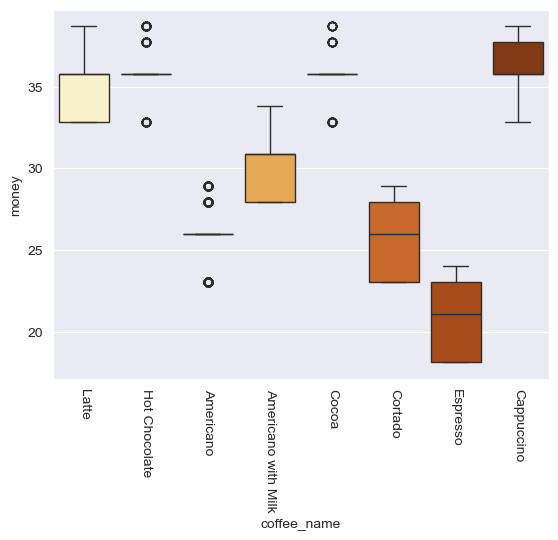

In [440]:
sns.boxplot(x = 'coffee_name',y = 'money', data = df , hue = 'coffee_name' , palette="YlOrBr" , legend = False)
plt.xticks(rotation=-90)
plt.show()

In [ ]:
# أكتر ساعات اليوم ازدحاما بالمبيعات

In [216]:
l = df['hour_of_day'].value_counts().sort_values(ascending=False)
l

hour_of_day
10    328
11    283
16    278
9     242
12    241
17    237
15    236
8     235
19    229
14    225
13    225
18    218
21    195
20    169
22    113
7      88
6       5
Name: count, dtype: int64

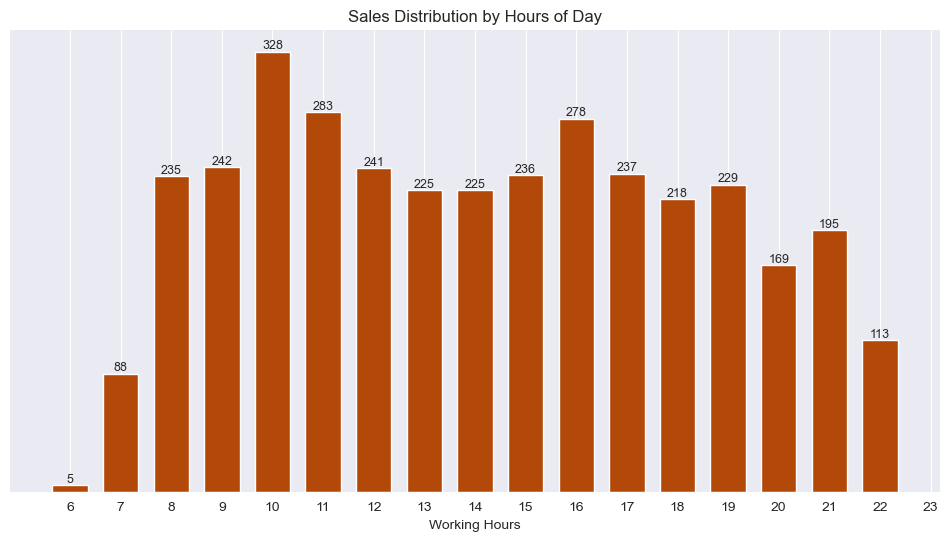

In [396]:
sns.set_style('darkgrid')
plt.figure(figsize=(12, 6))
plt.bar(l.index, l.values, color = '#B24909',width = .7)
plt.xticks(np.arange(6,24,1))
plt.yticks([])
a = plt.gca()
a.spines[['top','right','left']].set_visible( False)
plt.title('Sales Distribution by Hours of Day')
plt.xlabel('Working Hours')
a.bar_label(a.containers[0],fontsize = 9)
plt.show()

In [ ]:
# يوضح توزيع المبيعات حسب الساعة مقابل يوم الأسبوع Heatmap رسم

In [383]:
h = df.groupby('Weekday')['hour_of_day'].value_counts().reset_index()
h

,Weekday,hour_of_day,count
0,Fri,9,51
1,Fri,8,49
2,Fri,10,43
3,Fri,17,42
4,Fri,12,37
...,...,...,...
109,Wed,9,25
110,Wed,20,25
111,Wed,7,17
112,Wed,14,15


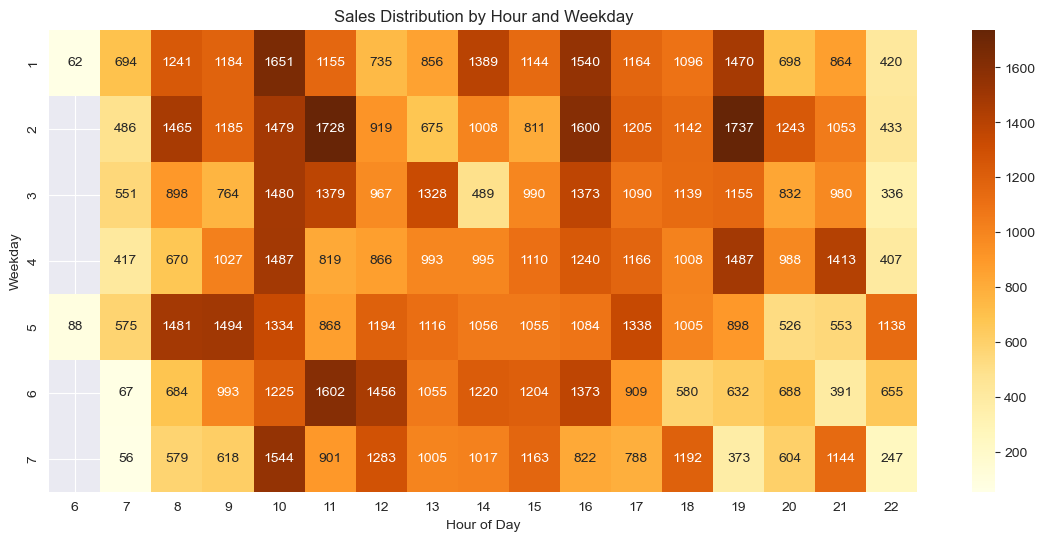

In [395]:
h = df.pivot_table(
    index='Weekdaysort',
    columns='hour_of_day',
    values='money',
    aggfunc='sum'
)

plt.figure(figsize=(14, 6))
sns.heatmap(
    h,
    annot=True,
    fmt='.0f',
    cmap='YlOrBr'
)
plt.title('Sales Distribution by Hour and Weekday')
plt.xlabel('Hour of Day')
plt.ylabel('Weekday')
plt.show()

In [ ]:
# هل المبيعات في الصباح مختلفة عن بعد الظهر والليل من حيث الكمية ونوع المشروب المطلوب؟

In [356]:
g = df.groupby('Time_of_Day')['coffee_name'].value_counts().reset_index()
g

,Time_of_Day,coffee_name,count
0,Afternoon,Latte,270
1,Afternoon,Americano with Milk,239
2,Afternoon,Americano,233
3,Afternoon,Cappuccino,164
4,Afternoon,Cortado,88
5,Afternoon,Hot Chocolate,80
6,Afternoon,Cocoa,75
7,Afternoon,Espresso,56
8,Morning,Americano with Milk,331
9,Morning,Americano,219


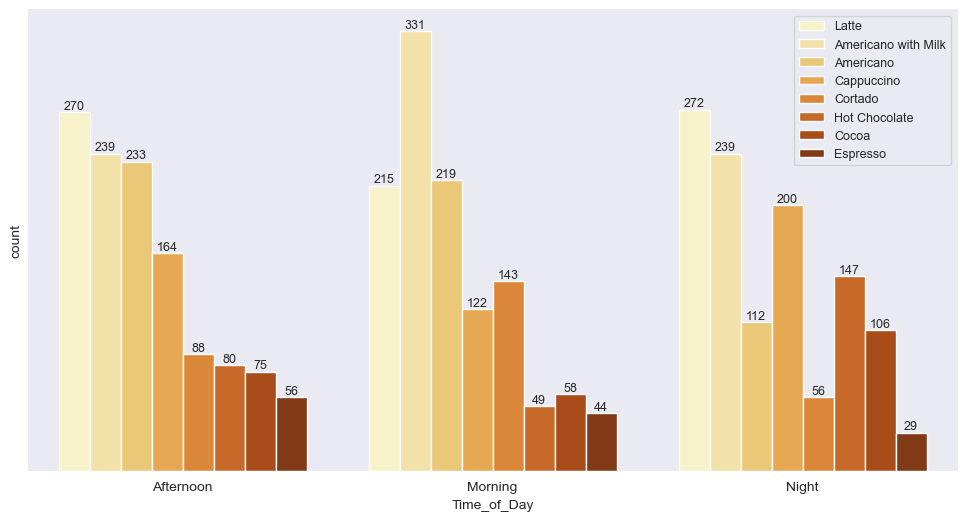

In [357]:
sns.set_style('darkgrid')
plt.figure(figsize=(12,6))
sns.barplot(x = 'Time_of_Day' , y = 'count' , data = g , hue = 'coffee_name' , palette = 'YlOrBr')
plt.yticks([])
b = plt.gca()
b.spines[['top','right','left']].set_visible( False)
for container in b.containers:
  b.bar_label(container,fontsize = 9)
plt.legend(fontsize = 9)
plt.show()

In [ ]:
# إيه أكتر أيام الأسبوع مبيعا؟ 

In [241]:
j = df.groupby('Weekday')['money'].sum().sort_values(ascending=False)
j

Weekday
Tue    18168.38
Mon    17363.10
Fri    16802.66
Thu    16091.40
Wed    15750.46
Sat    14733.52
Sun    13336.06
Name: money, dtype: float64

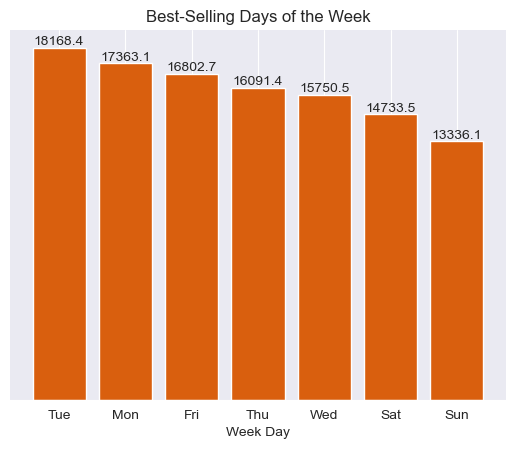

In [358]:
sns.set_style('darkgrid')
plt.bar(j.index , j.values , color = '#d95f0e')
plt.title('Best-Selling Days of the Week')
plt.yticks([])
plt.xlabel('Week Day')
s = plt.gca()
s.spines[['top','right','left']].set_visible( False)
s.bar_label(s.containers[0])
plt.show()

In [ ]:
#  في الزيادة والنقصان؟ (trend )هل الويكند مختلف عن أيام الأسبوع وهل فيه اتجاه

In [204]:
t = df[df['Weekday'].isin(['Sun','Sat'])].groupby('Weekday').size().mean()
print(t)
c = df[df['Weekday'].isin(['Mon','Tue','Wed','Thu','Fri'])].groupby('Weekday').size().mean()
print(c)

444.5
531.6


In [ ]:
# هل فيه شهور بمبيعات أعلى من غيرها؟

In [243]:
v = df.groupby('Month_name')['money'].sum().sort_values(ascending=False)
v

Month_name
Mar    15891.64
Oct    13891.16
Feb    13215.48
Sep     9988.64
Nov     8590.54
Dec     8237.74
May     8164.42
Jun     7617.76
Aug     7613.84
Jul     6915.94
Jan     6398.86
Apr     5719.56
Name: money, dtype: float64

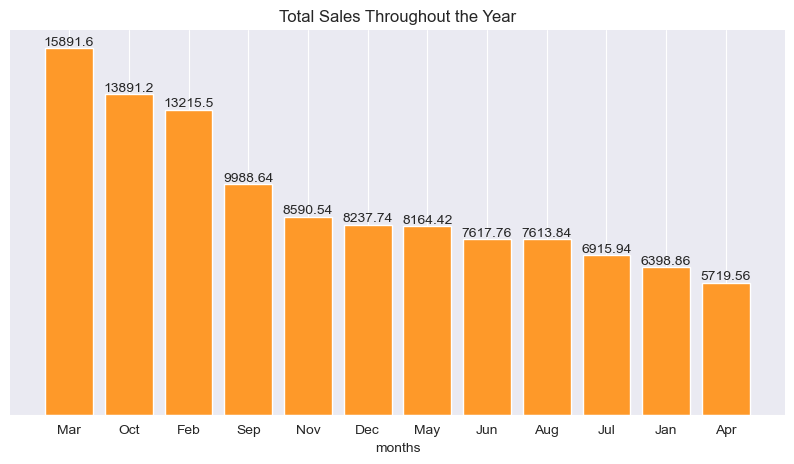

In [359]:
sns.set_style('darkgrid')
plt.figure(figsize=(10,5))
plt.bar(v.index , v.values , color = '#fe9929')
plt.title('Total Sales Throughout the Year')
plt.yticks([])
plt.xlabel('months')
s = plt.gca()
s.spines[['top','right','left']].set_visible( False)
s.bar_label(s.containers[0])
plt.show()

In [ ]:
# إجمالي الإيراد اليومي

In [404]:
u = df.groupby('Weekdaysort')['money'].sum().reset_index()
u

,Weekdaysort,money
0,1,17363.10
1,2,18168.38
2,3,15750.46
3,4,16091.40
4,5,16802.66
5,6,14733.52
6,7,13336.06


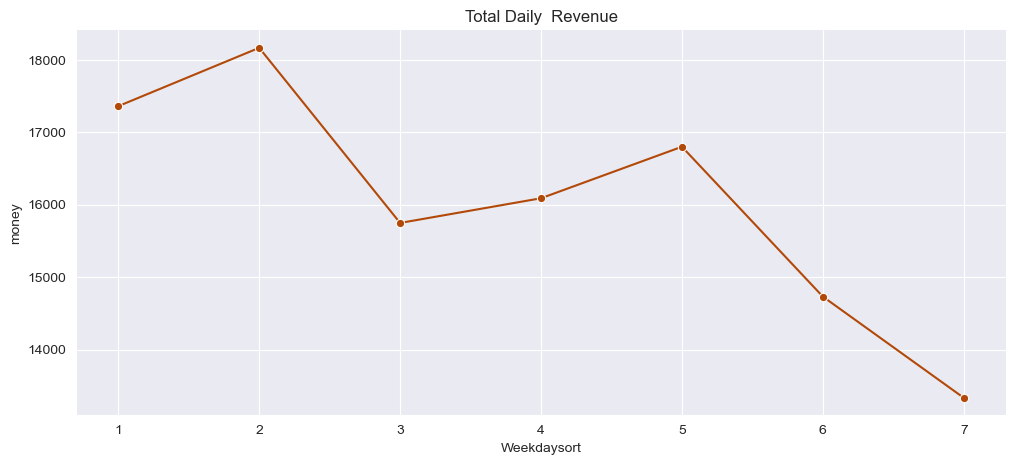

In [405]:
plt.figure(figsize=(12,5))
sns.lineplot(x = 'Weekdaysort', y = 'money', data = u , marker ='o', color = '#B24909')
u = plt.gca()
u.spines[['top','right']].set_visible(False)
plt.title('Total Daily  Revenue')
plt.show()

In [ ]:
# جدول يلخص متوسط الإيراد لكل يوم من أيام الأسبوع بالترتيب  

In [423]:
avg_weekday = df.groupby('Weekdaysort')['money'].mean()
avg_weekday

Weekdaysort
1    31.917463
2    31.762902
3    31.500920
4    31.551765
5    31.583947
6    31.347915
7    31.828305
Name: money, dtype: float64

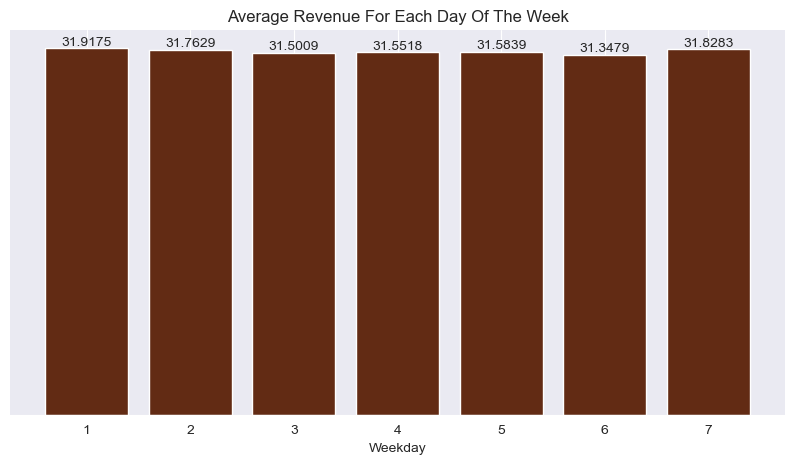

In [424]:
sns.set_style('darkgrid')
plt.figure(figsize=(10,5))
plt.bar(avg_weekday.index , avg_weekday.values , color = '#622B14')
plt.title('Average Revenue For Each Day Of The Week')
plt.yticks([])
plt.xlabel('Weekday')
s = plt.gca()
s.spines[['top','right','left']].set_visible( False)
s.bar_label(s.containers[0])
plt.show()

In [ ]:
# إجمالي الإيراد الشهري

In [406]:
u = df.groupby('Monthsort')['money'].sum().reset_index()
u

,Monthsort,money
0,1,6398.86
1,2,13215.48
2,3,15891.64
3,4,5719.56
4,5,8164.42
5,6,7617.76
6,7,6915.94
7,8,7613.84
8,9,9988.64
9,10,13891.16


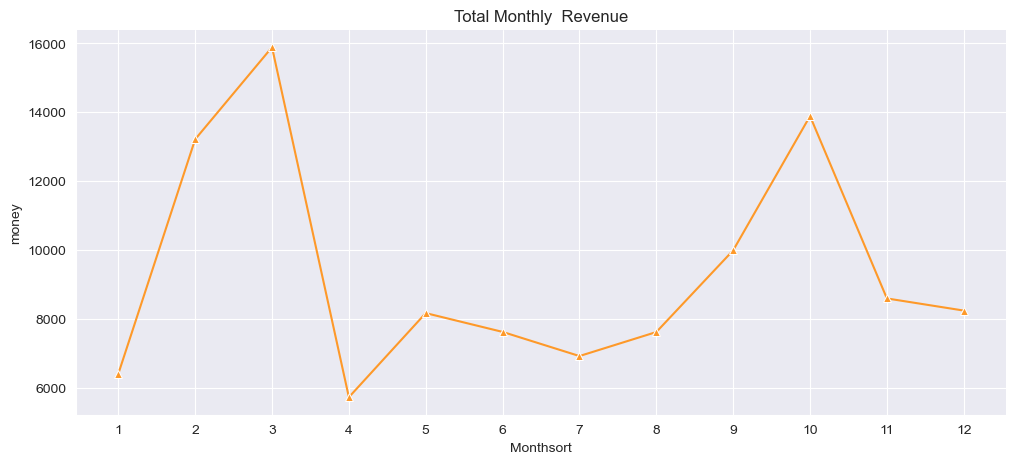

In [407]:
plt.figure(figsize=(12,5))
sns.lineplot(x = 'Monthsort', y = 'money', data = u , marker ='^', color = '#fe9929')
u = plt.gca()
u.spines[['top','right']].set_visible(False)
plt.xticks(np.arange(1,13,1))
plt.title('Total Monthly  Revenue')
plt.show()

In [ ]:
# جدول يلخص متوسط الإيراد لكل كل شهر بالترتيب 

In [443]:
avg_month = df.groupby('Monthsort')['money'].mean()
avg_month

Monthsort
1     31.835124
2     31.242270
3     32.169312
4     34.045000
5     33.877261
6     34.160359
7     29.181181
8     27.992059
9     29.036744
10    32.608357
11    33.168108
12    31.805946
Name: money, dtype: float64

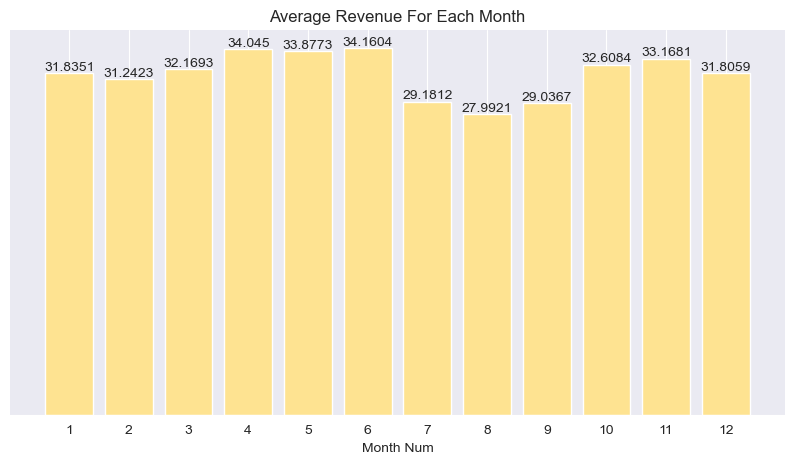

In [444]:
sns.set_style('darkgrid')
plt.figure(figsize=(10,5))
plt.bar(avg_month.index , avg_month.values , color = '#fee391')
plt.title('Average Revenue For Each Month')
plt.yticks([])
plt.xticks(np.arange(1,13,1))
plt.xlabel('Month Num')
s = plt.gca()
s.spines[['top','right','left']].set_visible( False)
s.bar_label(s.containers[0])
plt.show()

In [ ]:
# متوسط قيمة الفاتورة الواحدة 

In [313]:
z = df.groupby('hour_of_day')['money'].mean()
z

hour_of_day
6     29.880000
7     32.341136
8     29.863319
9     30.017686
10    31.093049
11    29.869611
12    30.786805
13    31.238933
14    31.883556
15    31.678051
16    32.488633
17    32.319662
18    32.855963
19    33.851354
20    33.011361
21    32.809949
22    32.169558
Name: money, dtype: float64

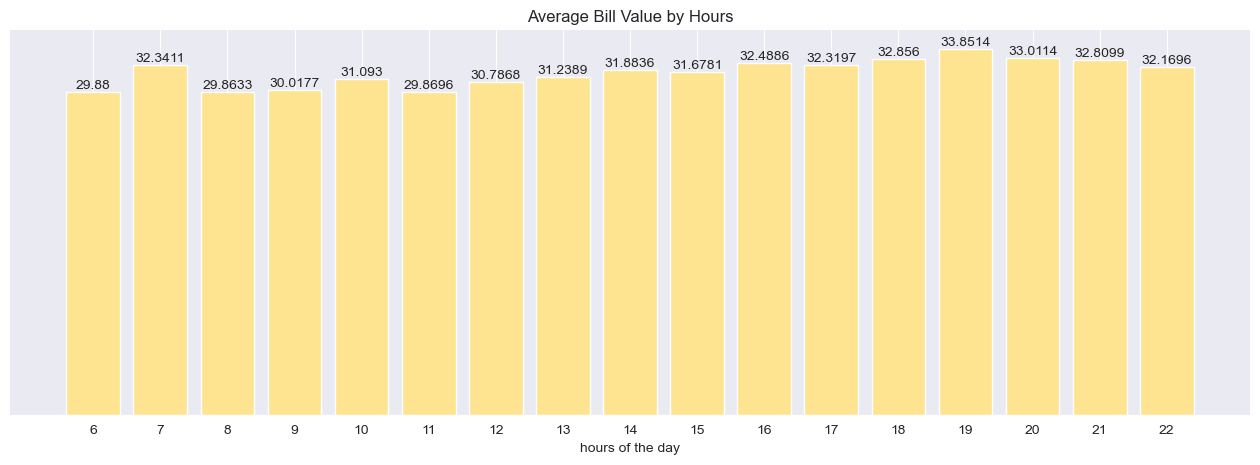

In [414]:
sns.set_style('darkgrid')
plt.figure(figsize=(16,5))
plt.bar(z.index , z.values , color = '#fee391')
plt.yticks([])
u = plt.gca()
u.spines[['top','right','left']].set_visible(False)
plt.xticks(np.arange(6,23,1))
u.bar_label(u.containers[0])
plt.xlabel('hours of the day')
plt.title('Average Bill Value by Hours')
plt.show()

In [335]:
o = df.groupby('coffee_name')['money'].mean()
o

coffee_name
Americano              25.975638
Americano with Milk    30.594710
Cappuccino             35.883004
Cocoa                  35.653389
Cortado                25.731220
Espresso               20.854884
Hot Chocolate          35.990797
Latte                  35.502378
Name: money, dtype: float64

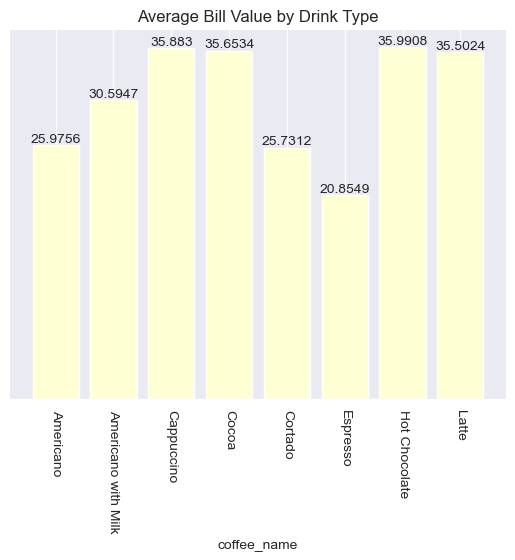

In [401]:
sns.set_style('darkgrid')
plt.bar(o.index , o.values , color = '#ffffd4')
u = plt.gca()
plt.yticks([])
u.spines[['top','right','left']].set_visible(False)
u.bar_label(u.containers[0])
plt.title('Average Bill Value by Drink Type')
plt.xticks(rotation=-90)
plt.xlabel('coffee_name')
plt.show()

In [ ]:
# هل فيه أيام أو ساعات معينة بإيراد أعلى بشكل ملحوظ يستاهل نركز عليها بعروض؟ 

In [ ]:
'''
Tuesday and monday  
hours  10,11,16 and 19
'''

In [ ]:
# إحصاء بسيط لعدد ونسبة كل طريقة دفع

In [403]:
payment = df['cash_type'].value_counts()
payment

cash_type
card    3547
Name: count, dtype: int64

In [ ]:
'The only payment method is by card '